Processing Activity A01: walk_forward


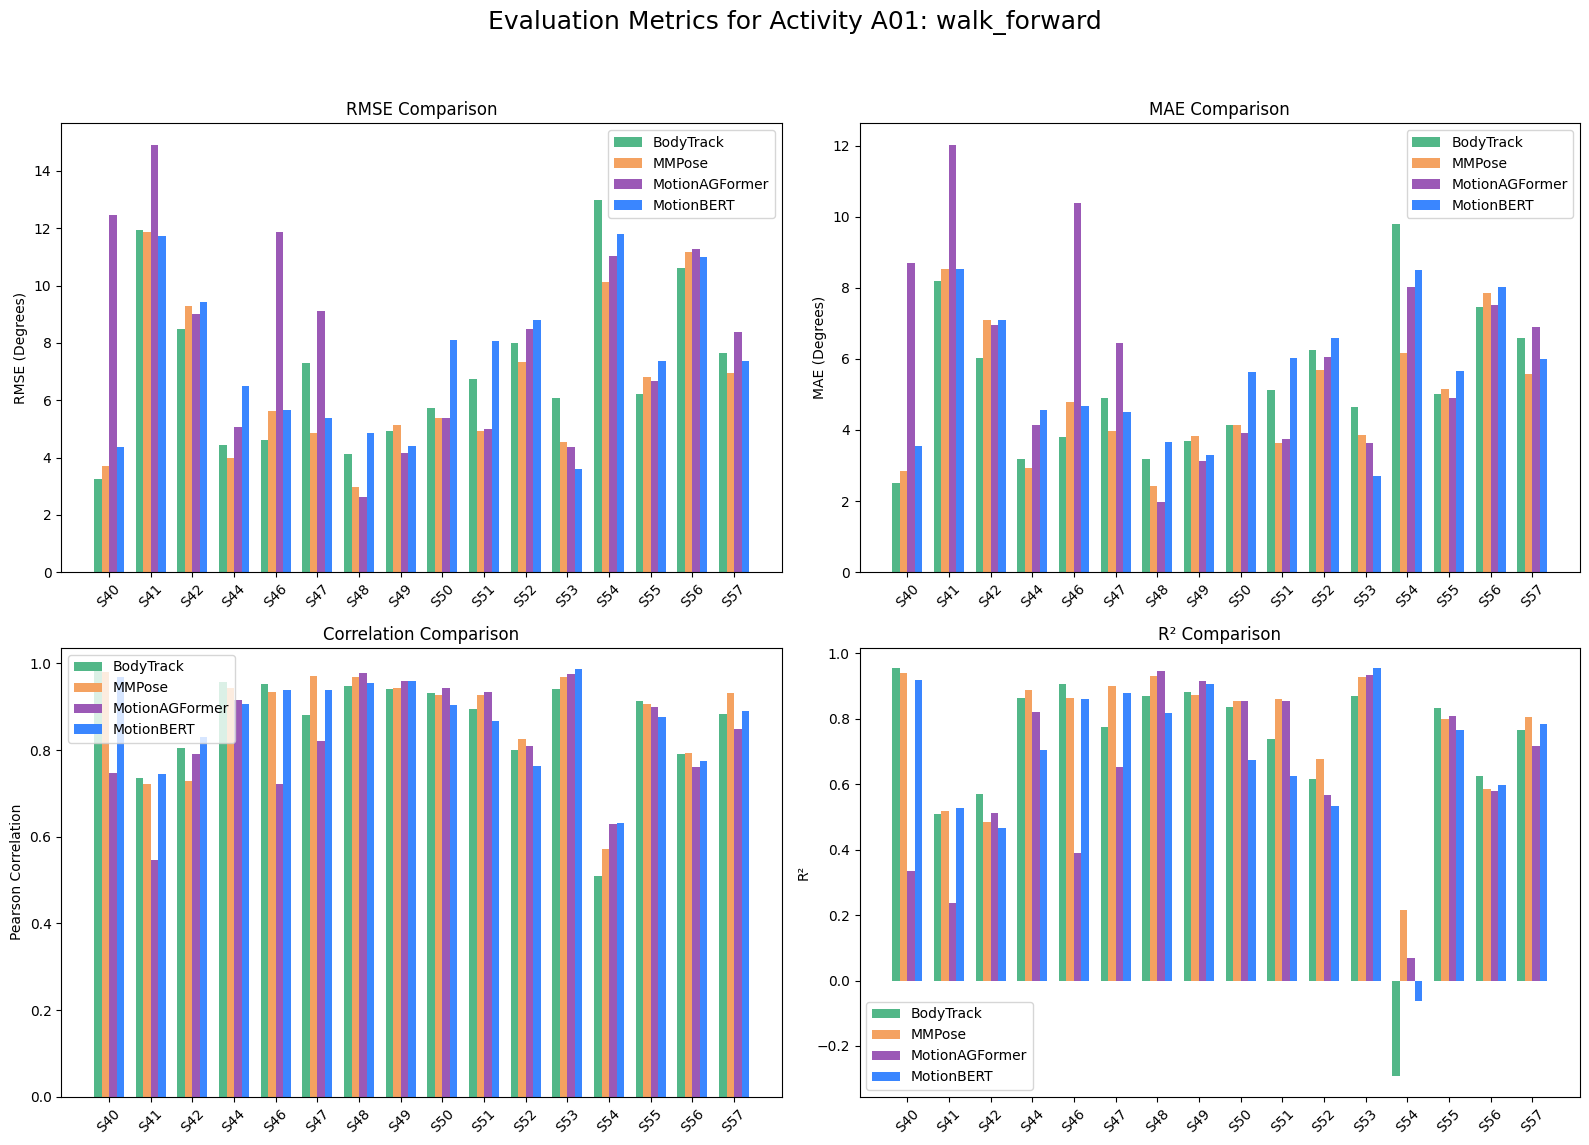

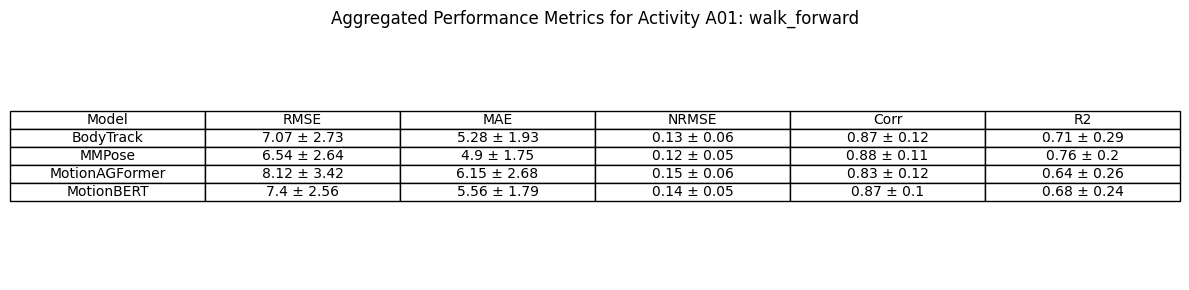

Processing Activity A02: walk_backward


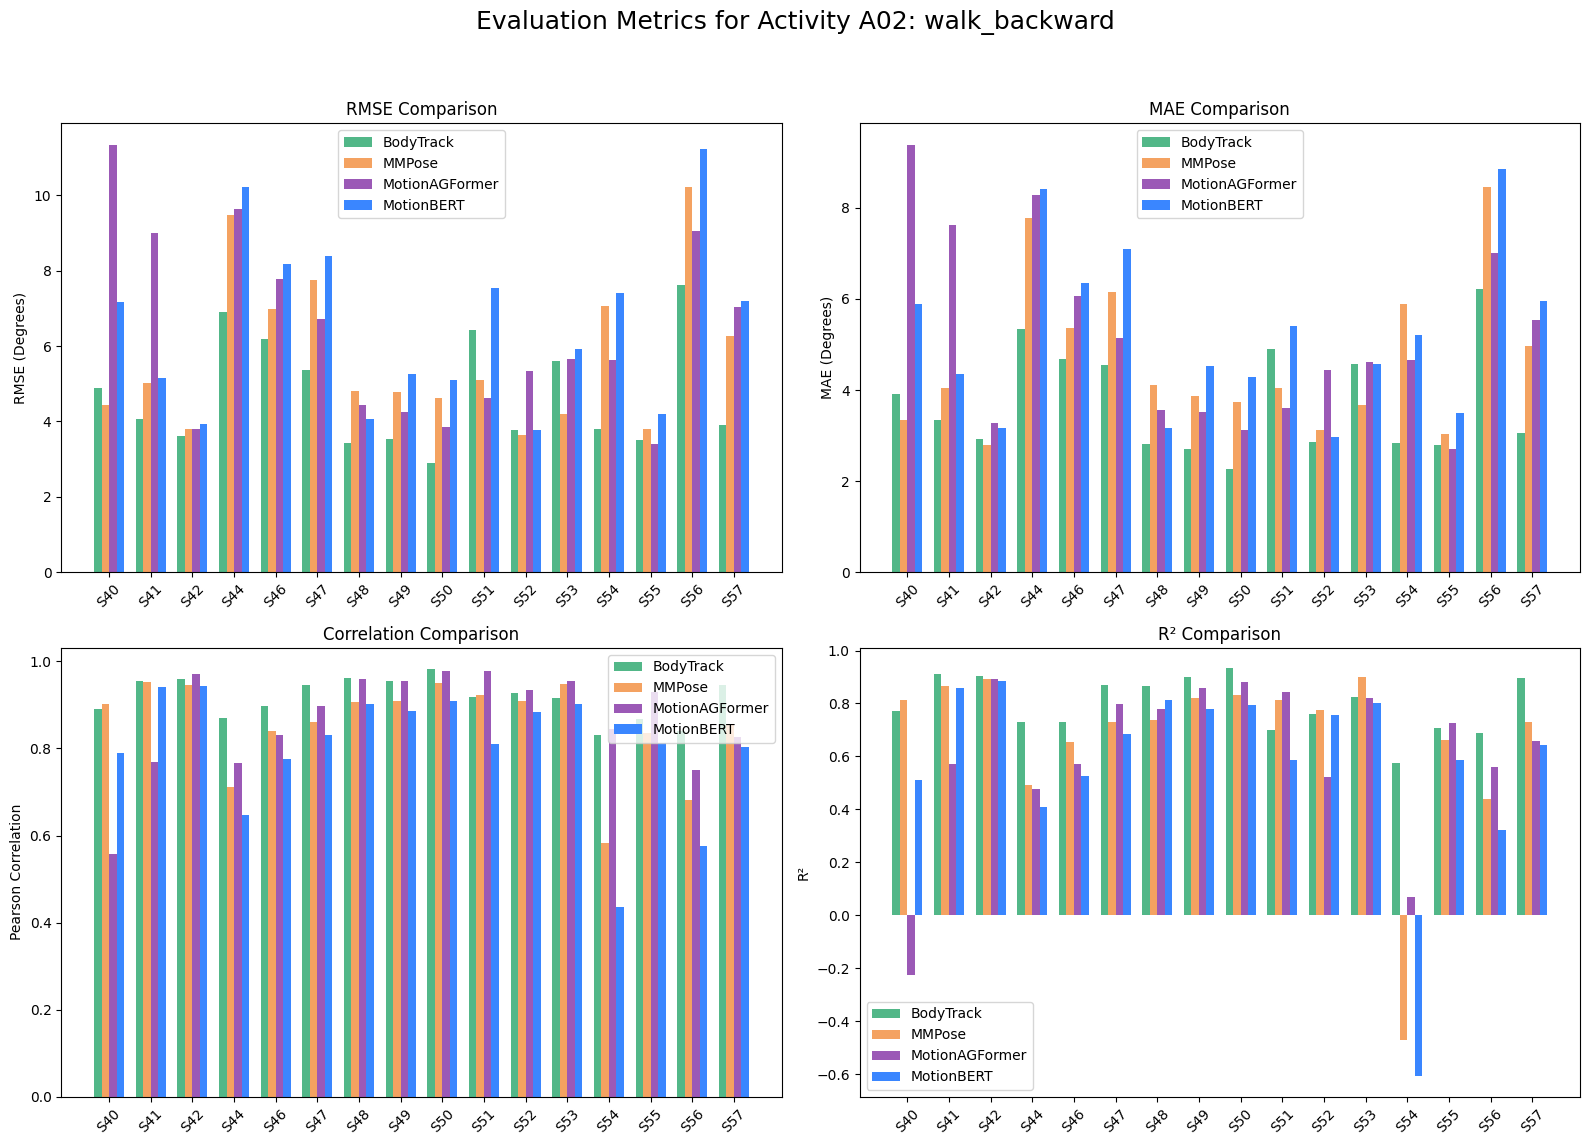

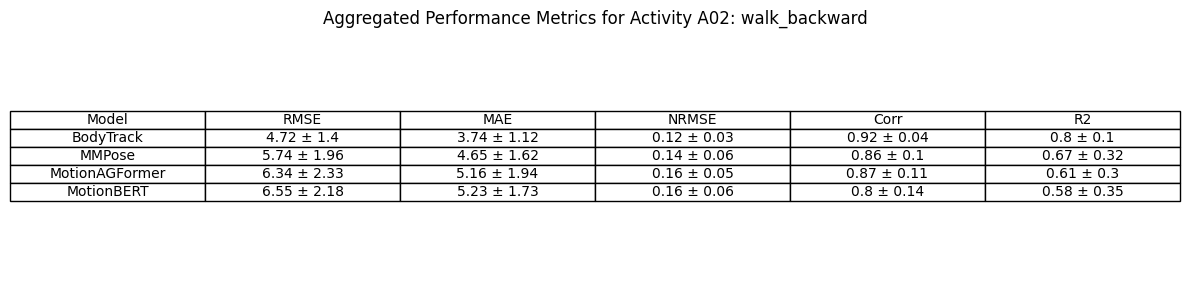

Processing Activity A03: walk_along


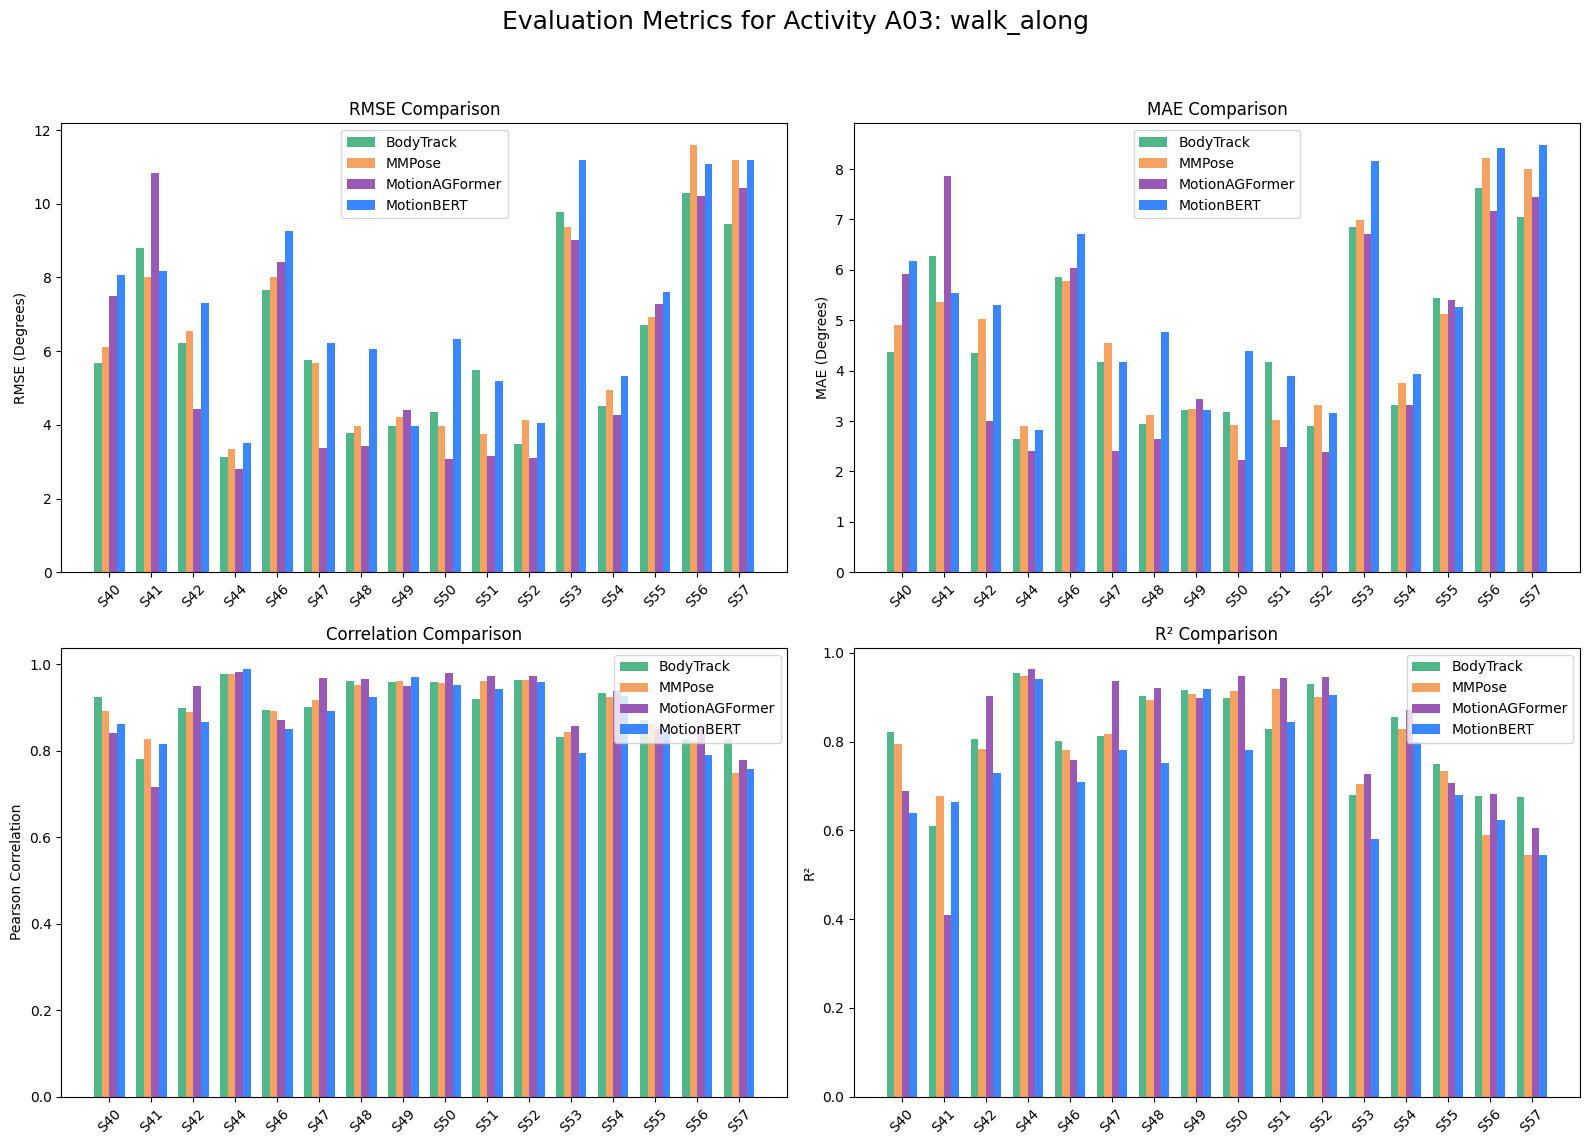

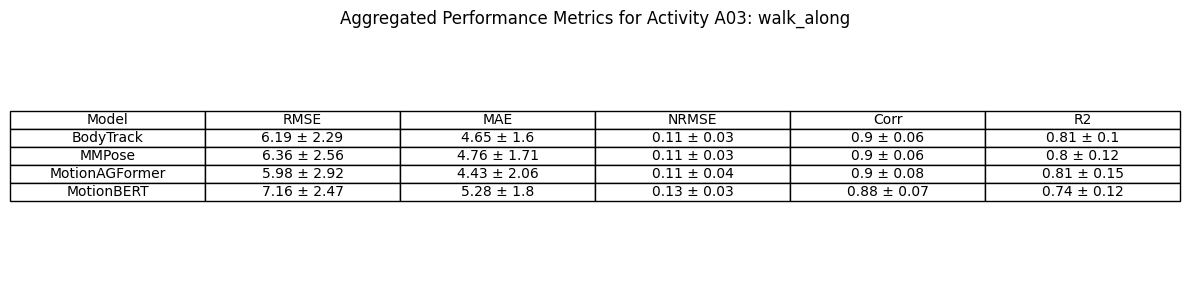

Processing Activity A04: sit_to_stand


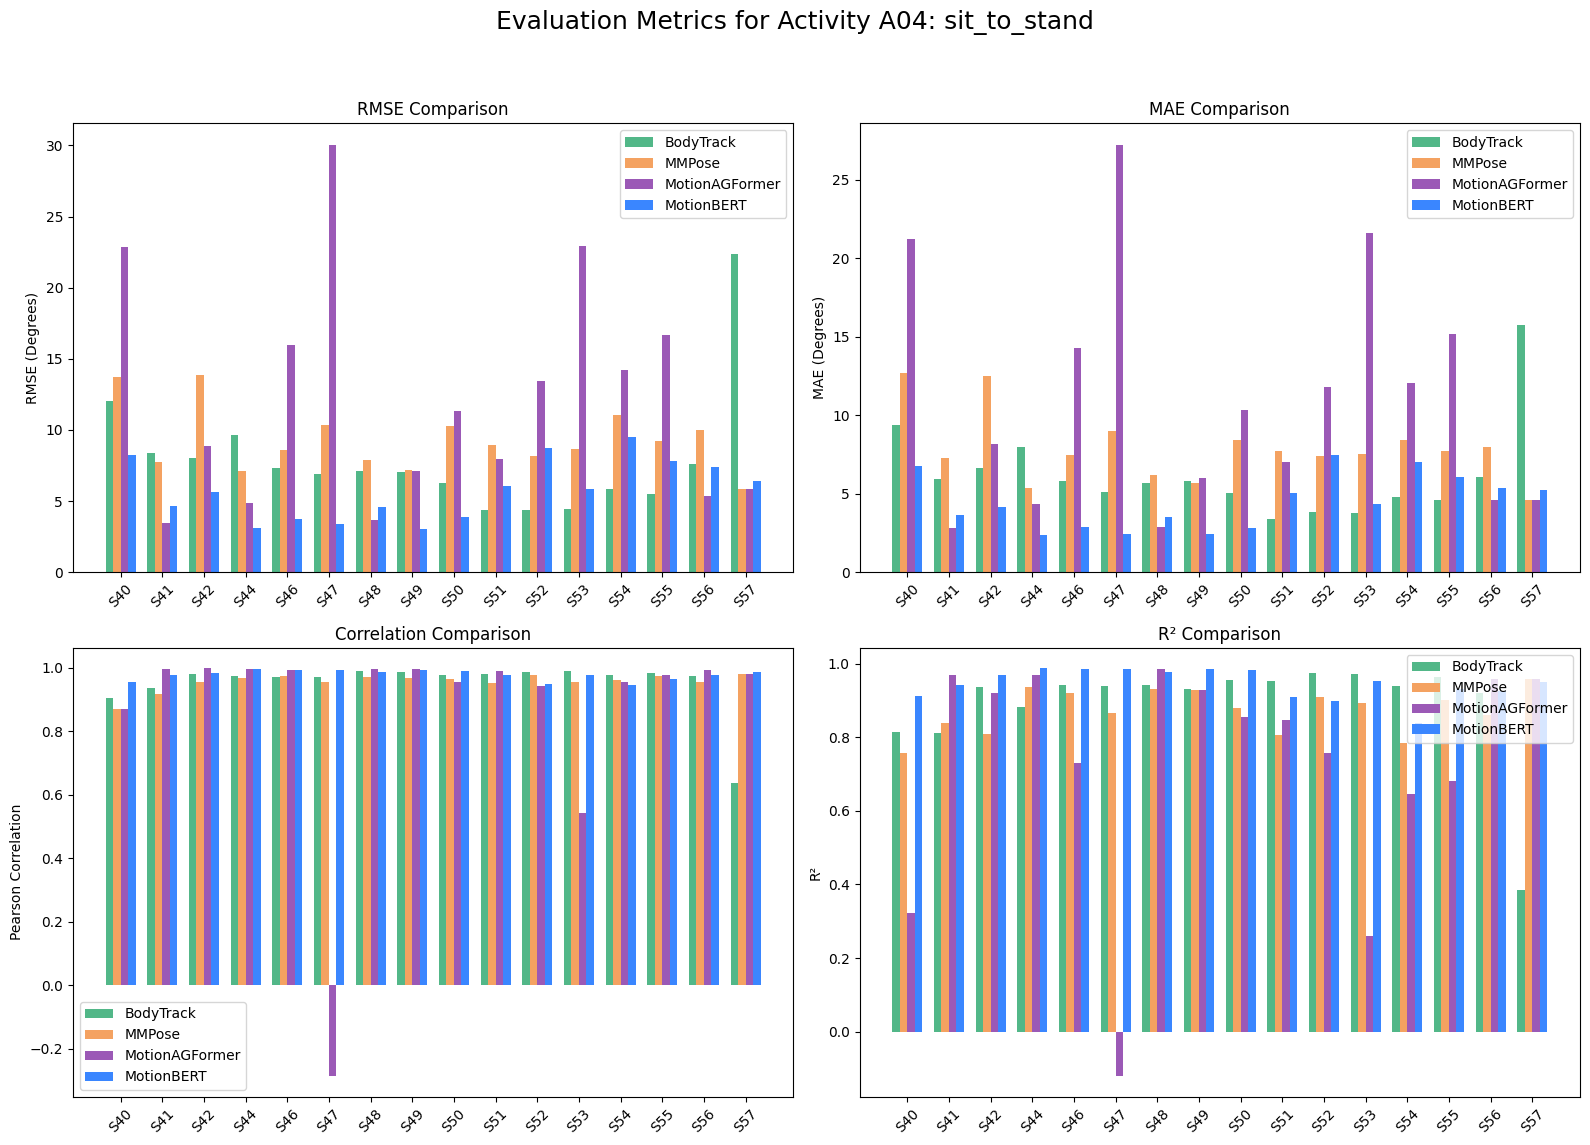

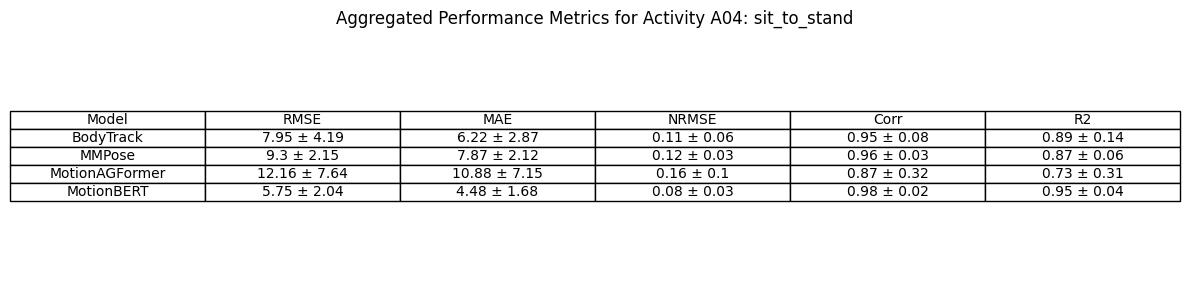

Processing Activity A05: move_right_arm


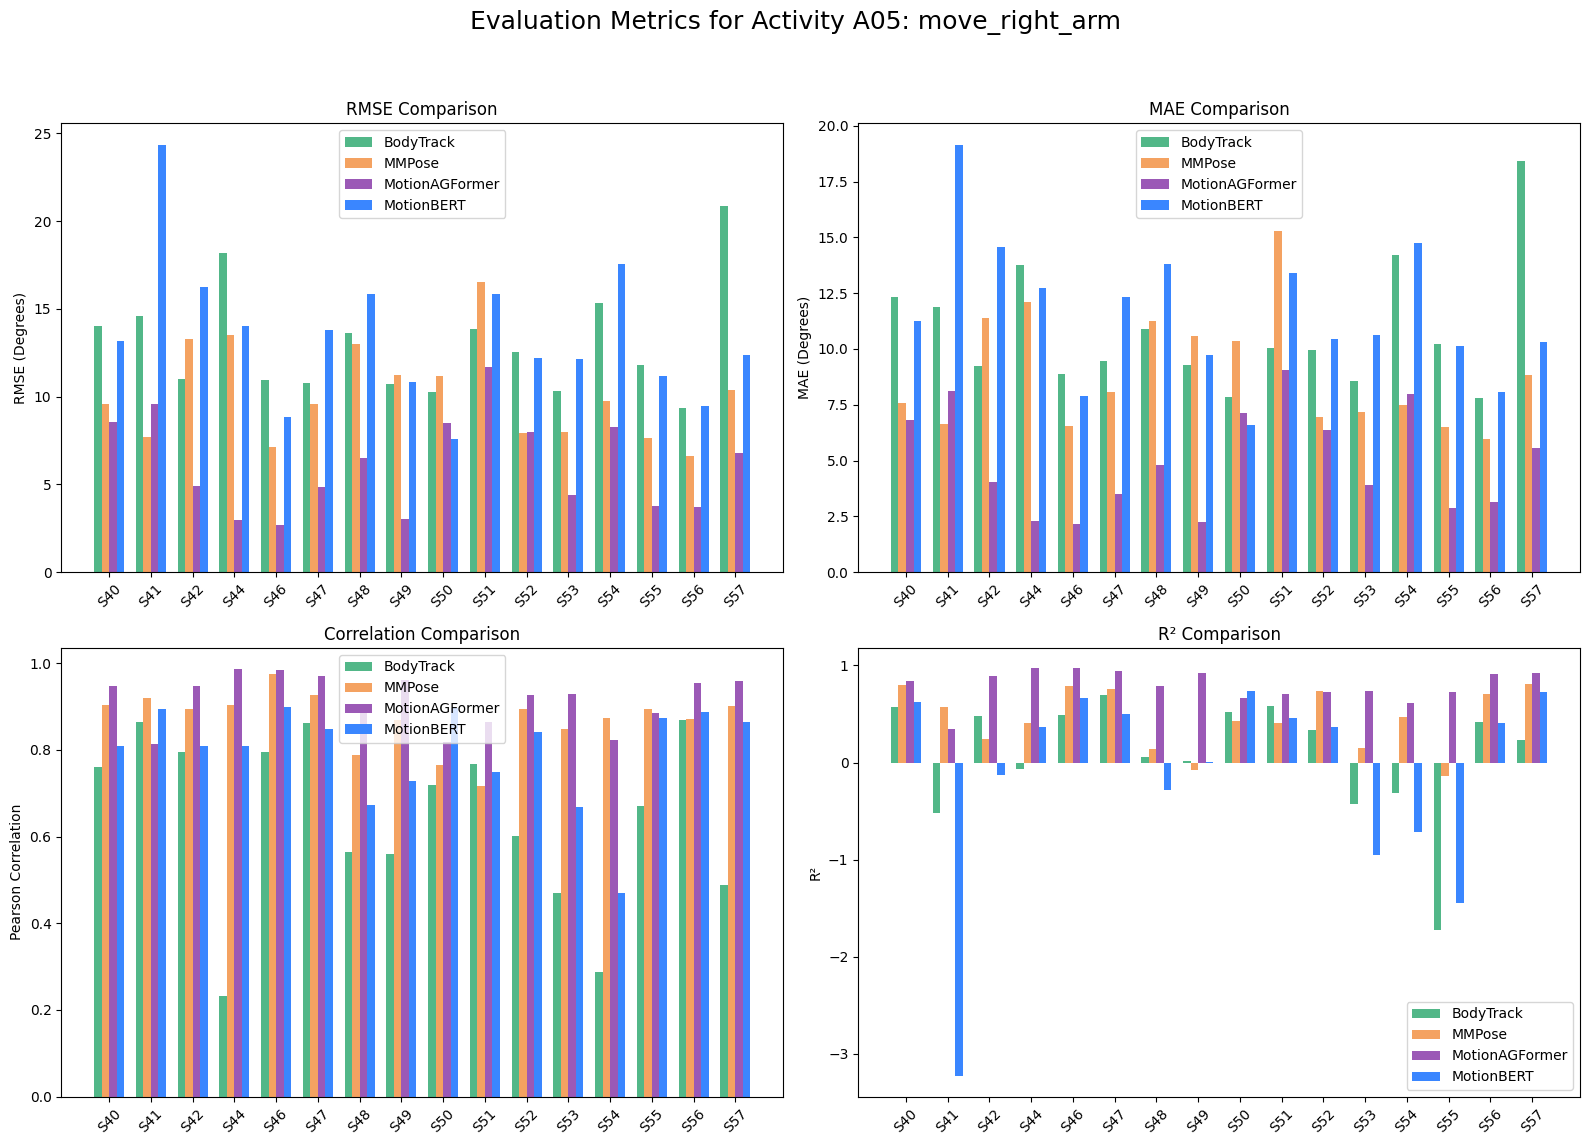

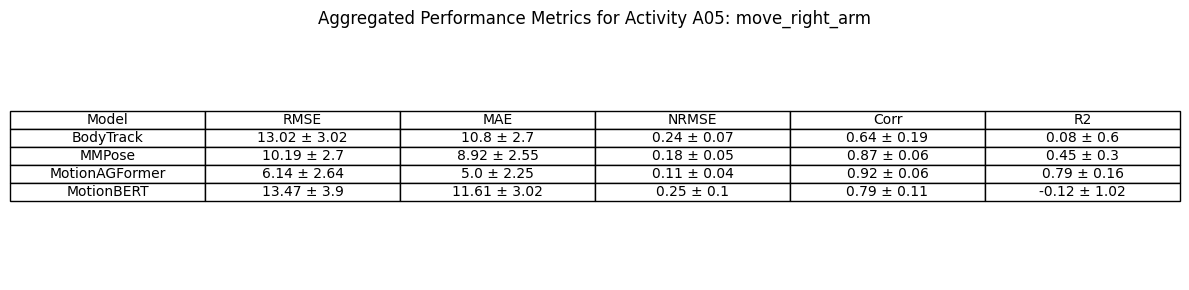

Processing Activity A06: move_left_arm


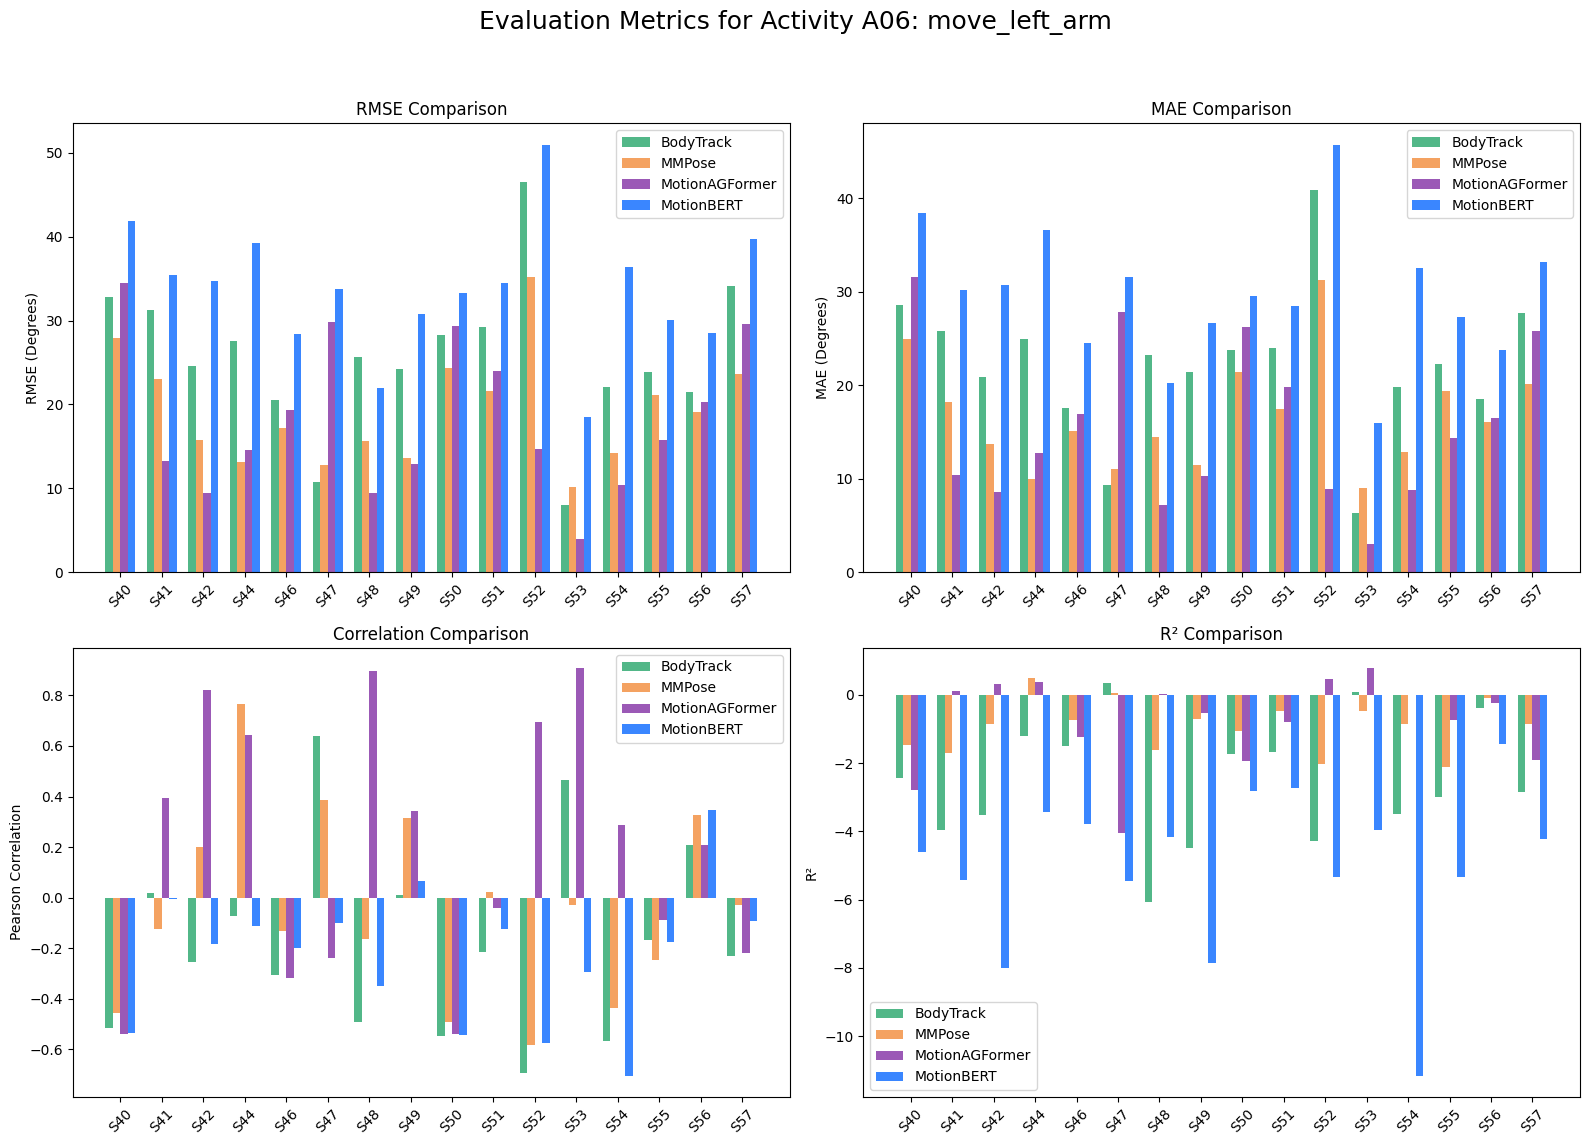

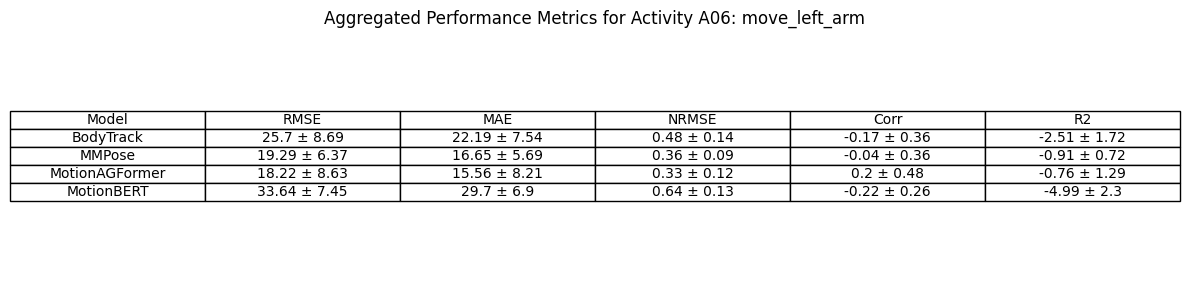

Processing Activity A07: drink_right_arm


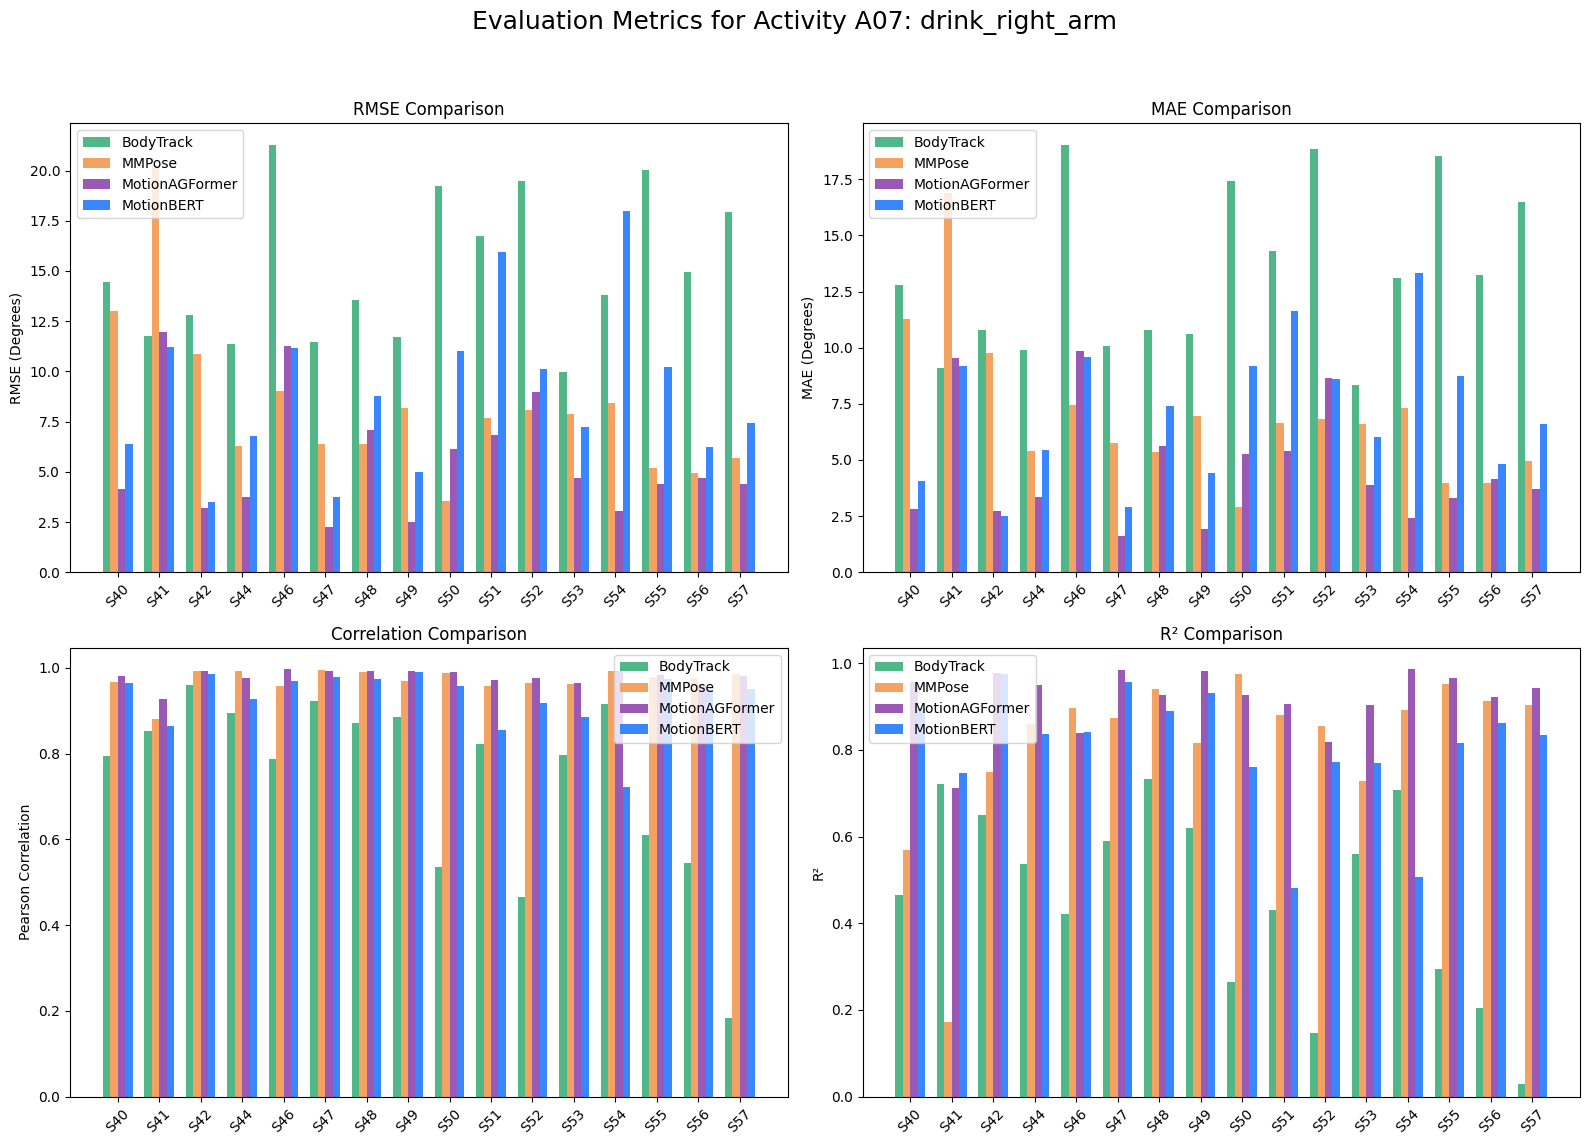

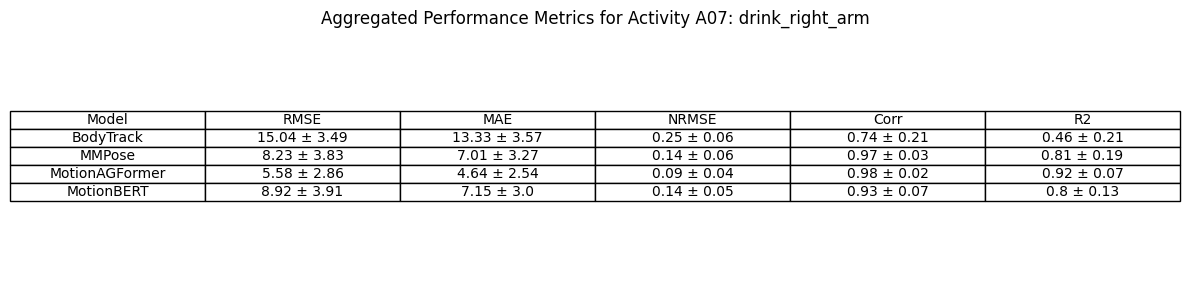

Processing Activity A08: drink_left_arm


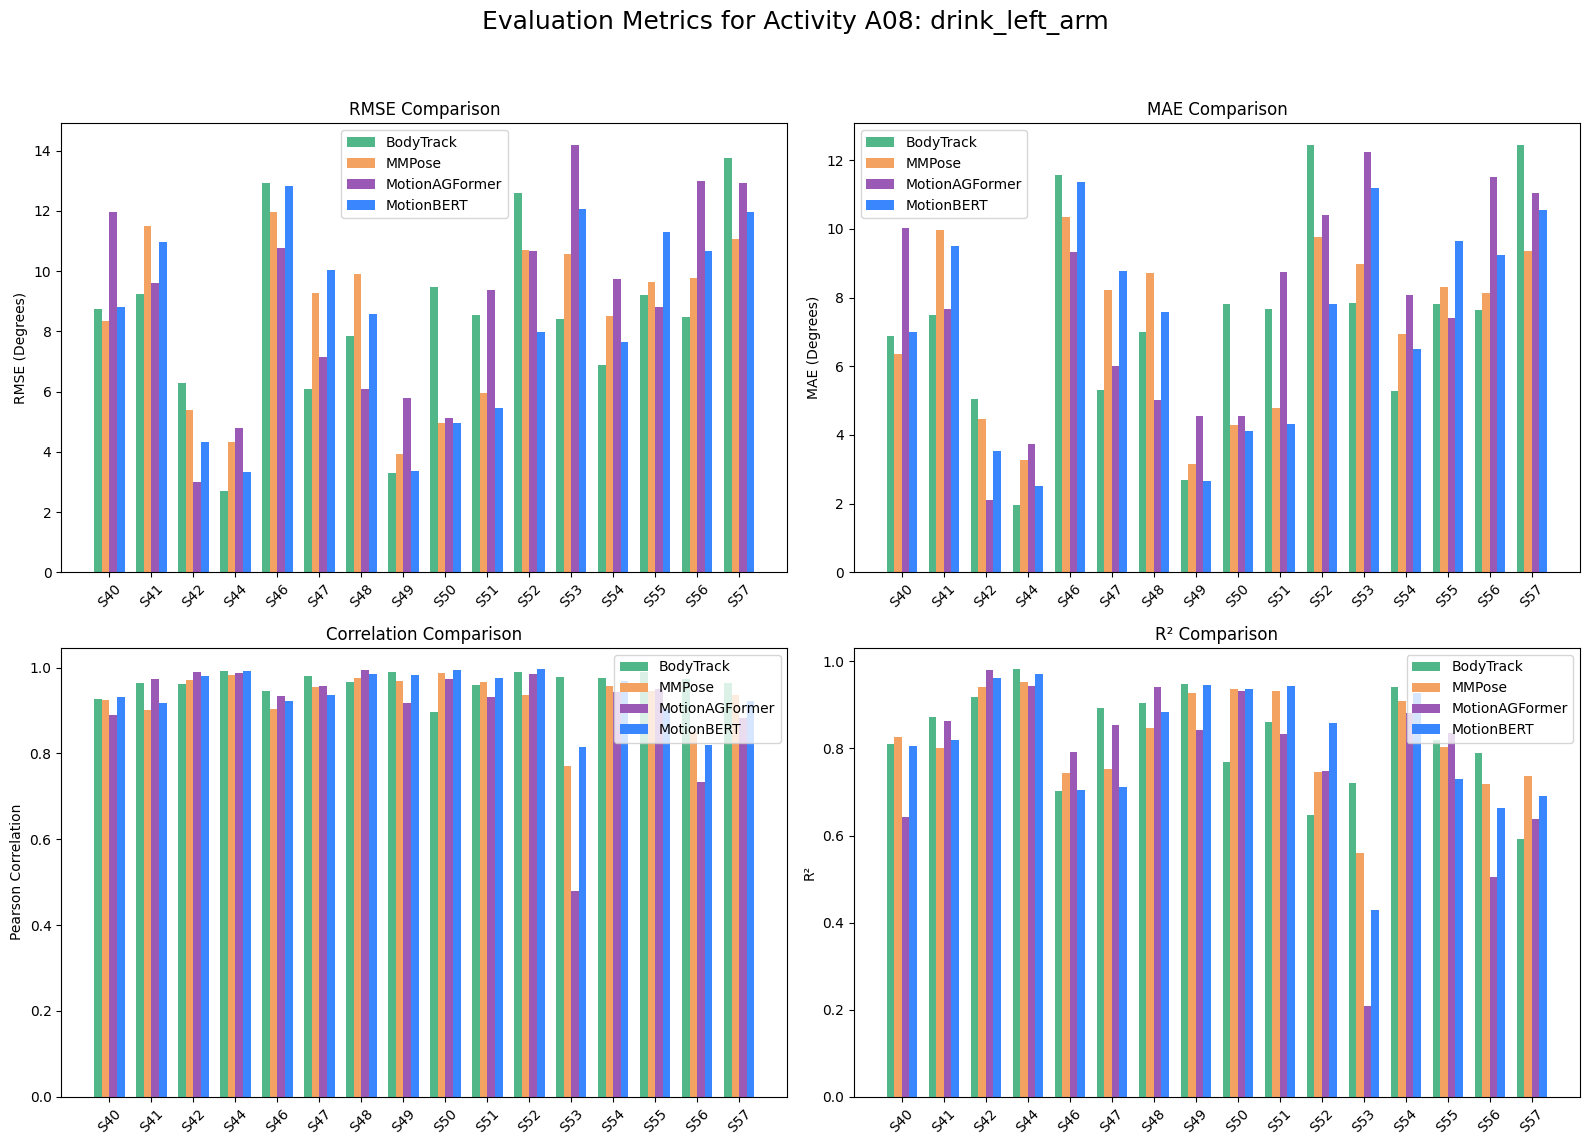

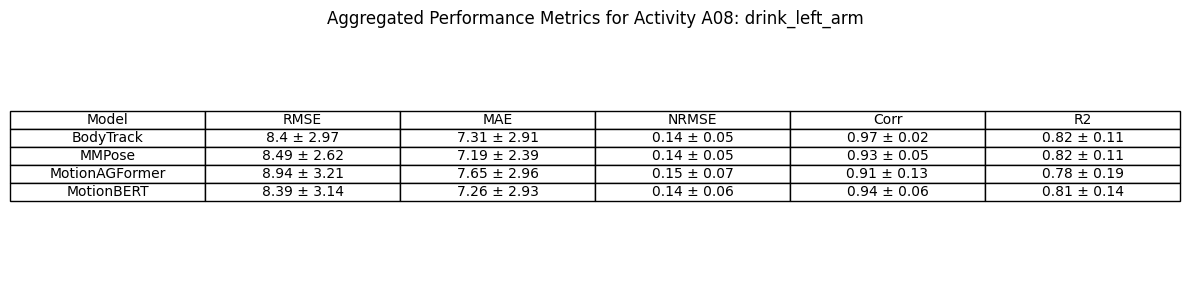

Processing Activity A09: assemble_both_arms


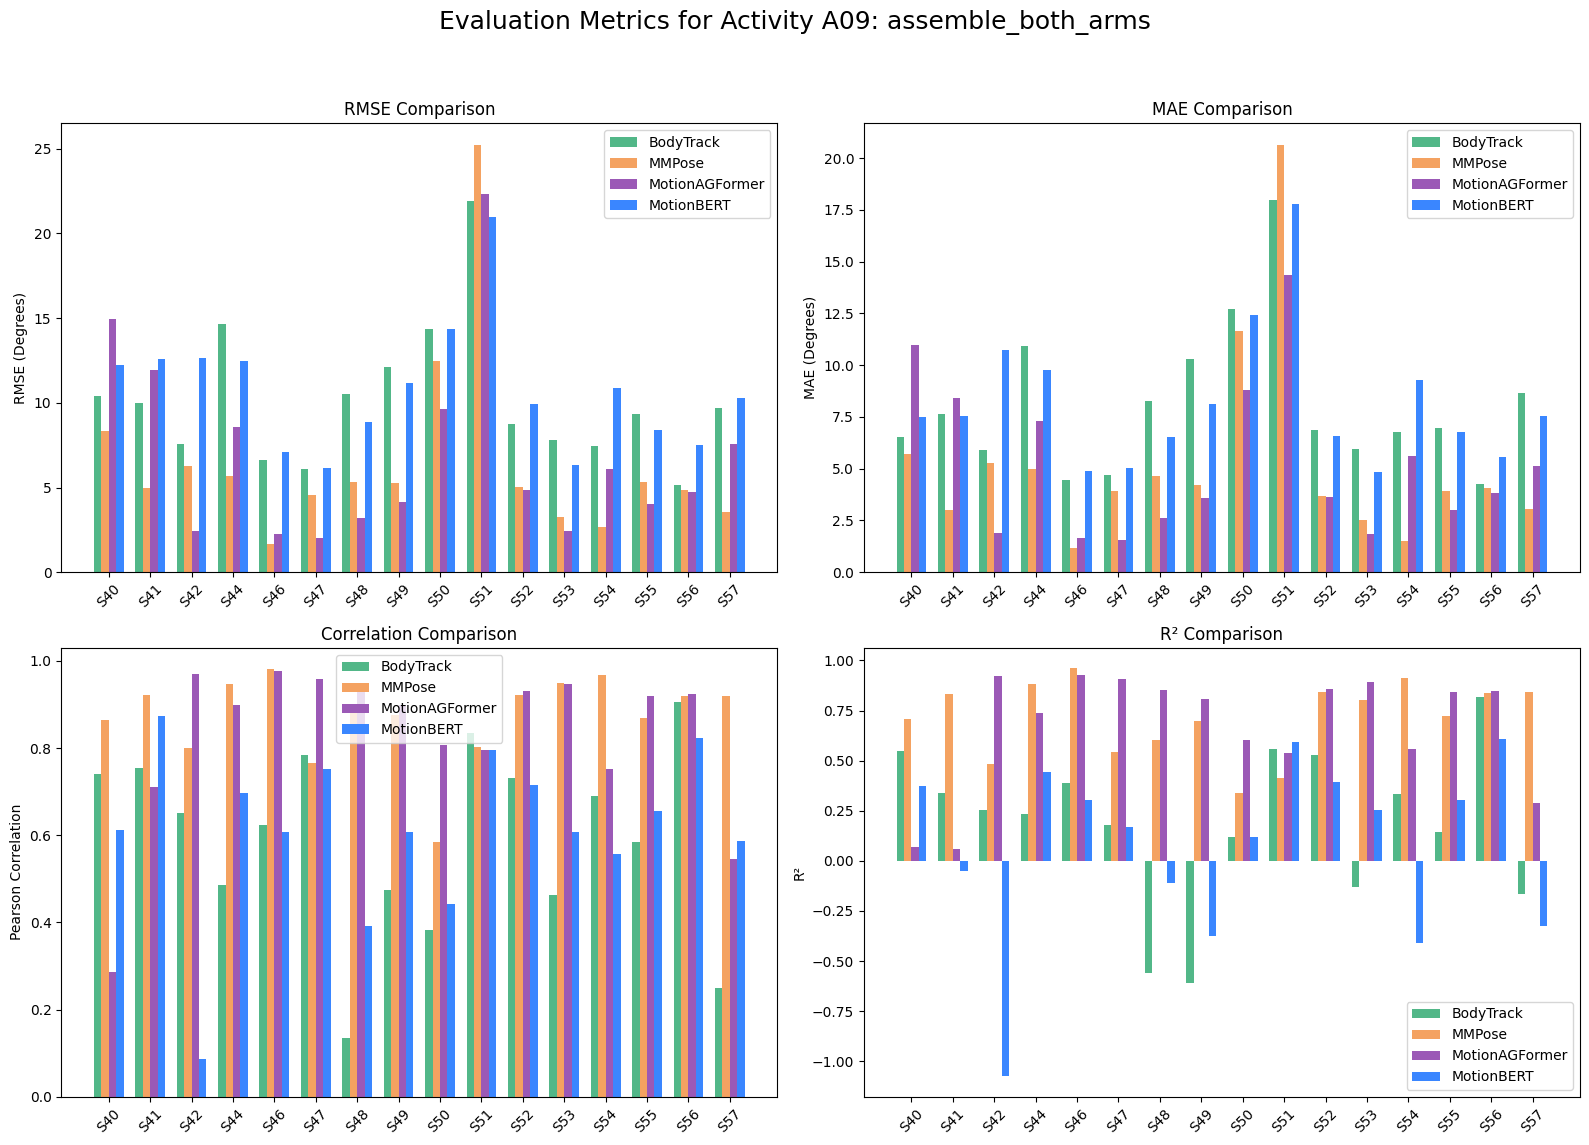

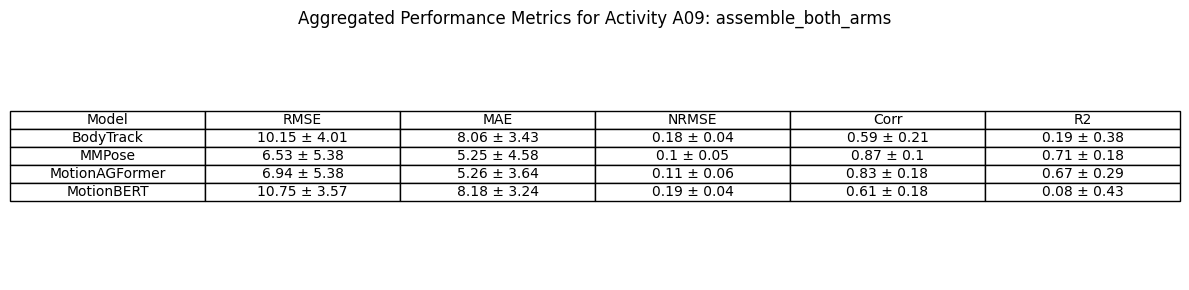

Processing Activity A10: throw_both_arms


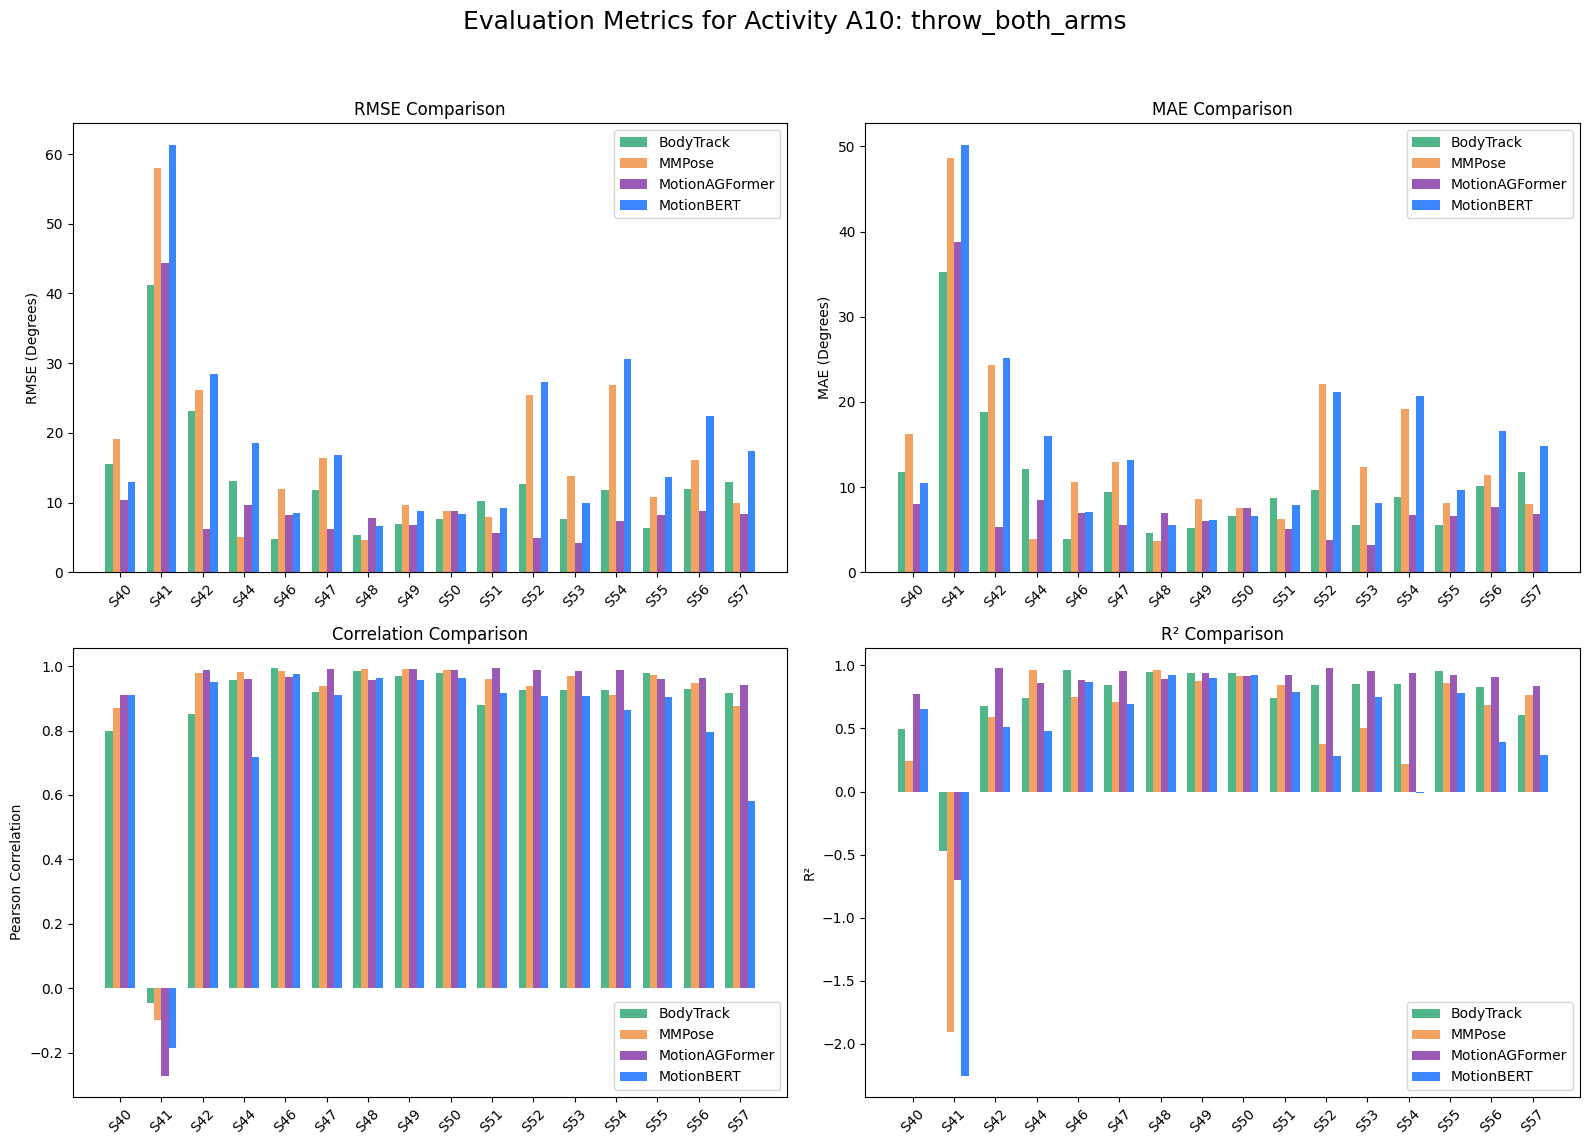

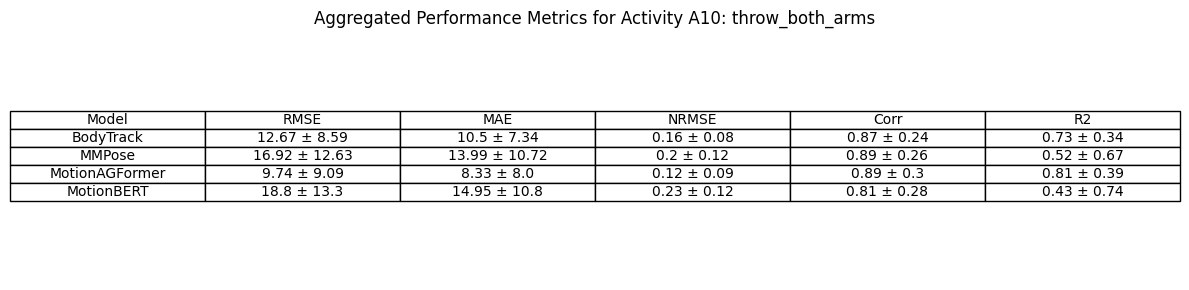

Processing Activity A11: reachup_right_arm


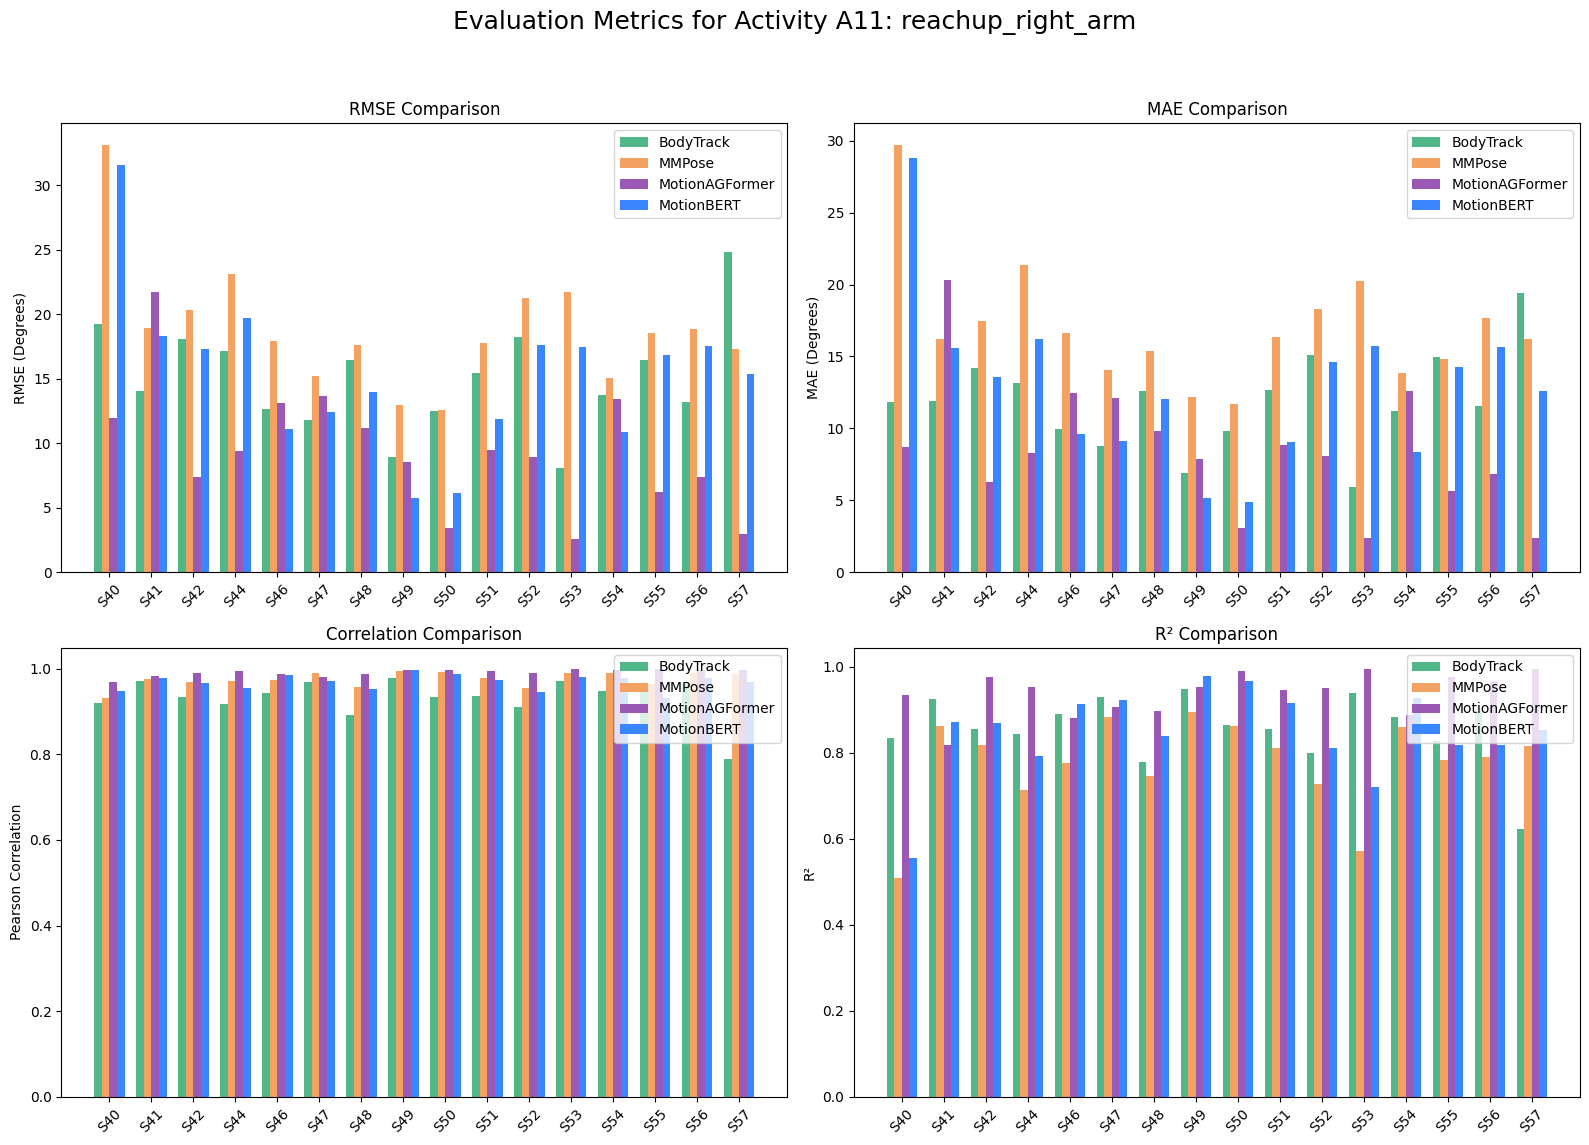

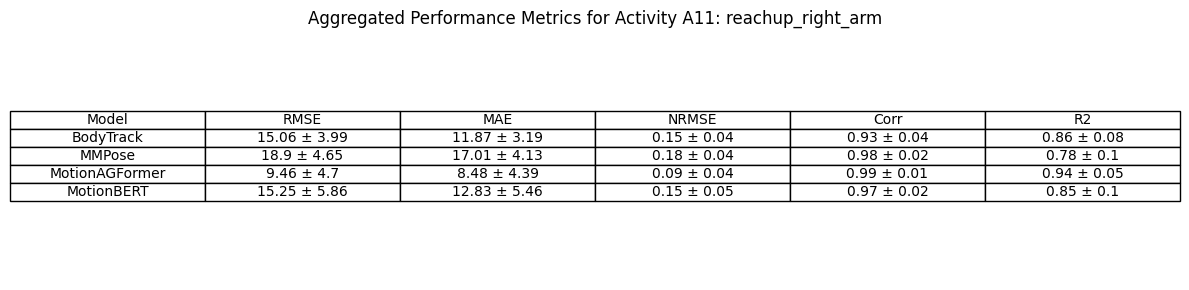

Processing Activity A12: reachup_left_arm


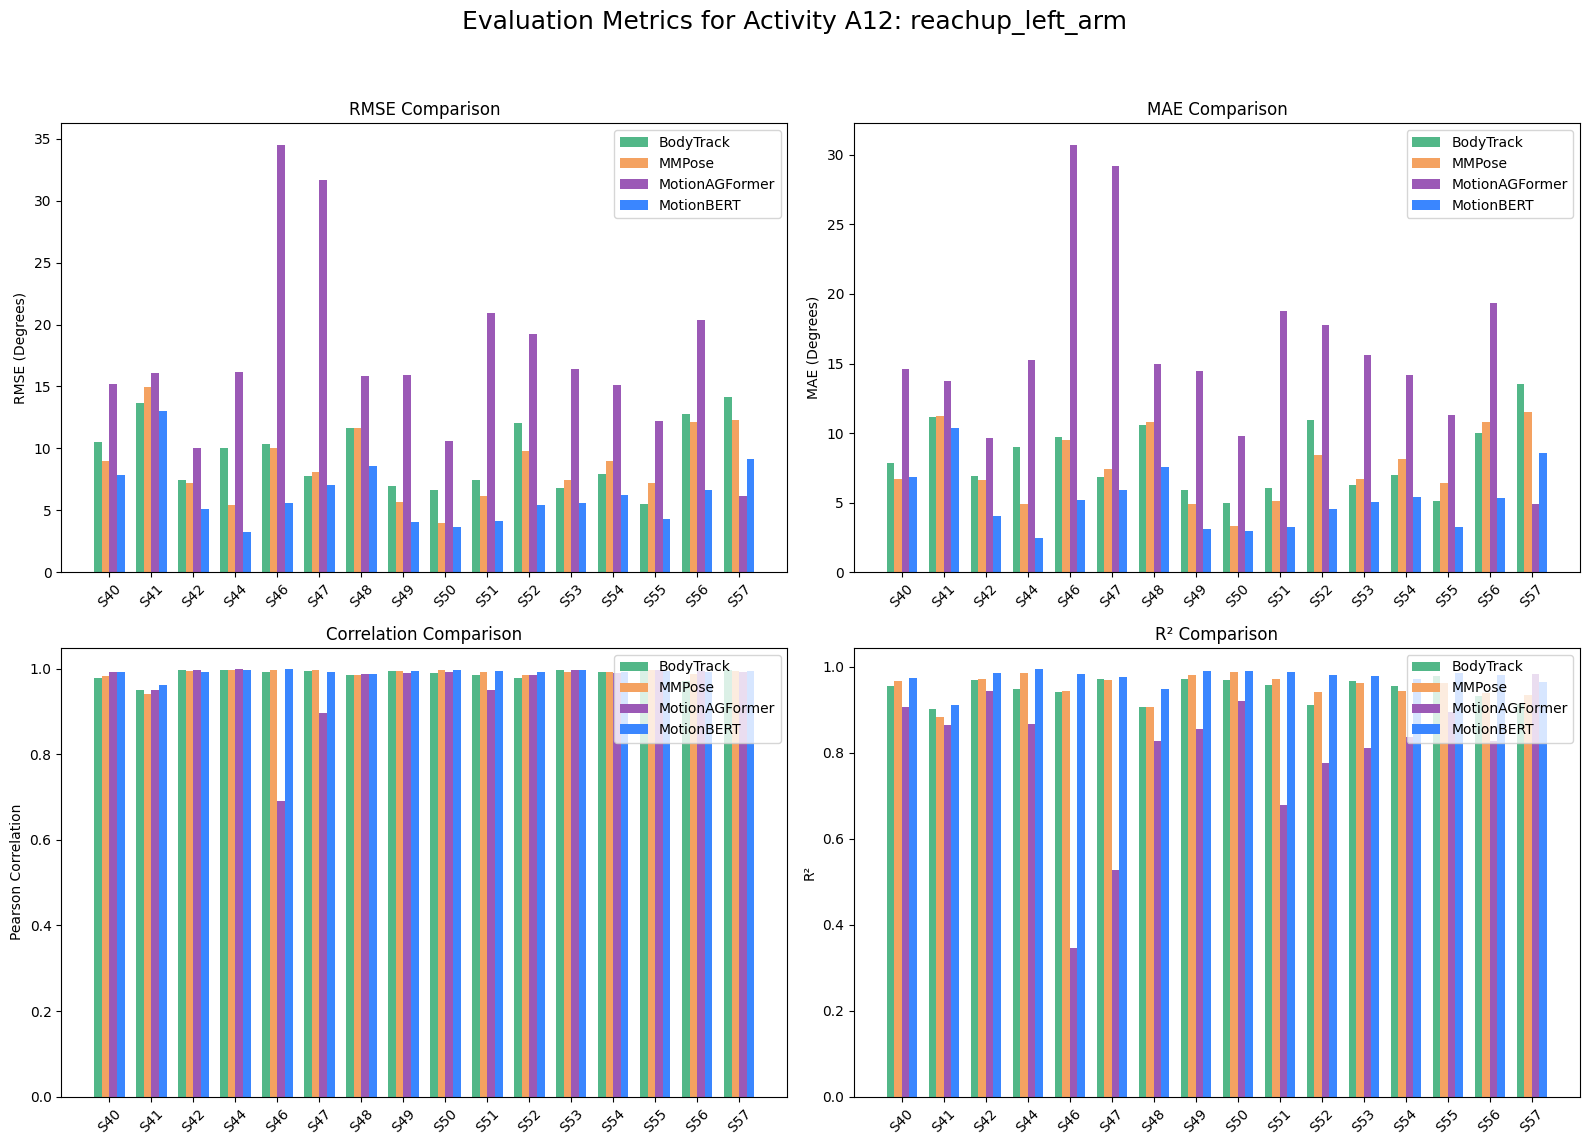

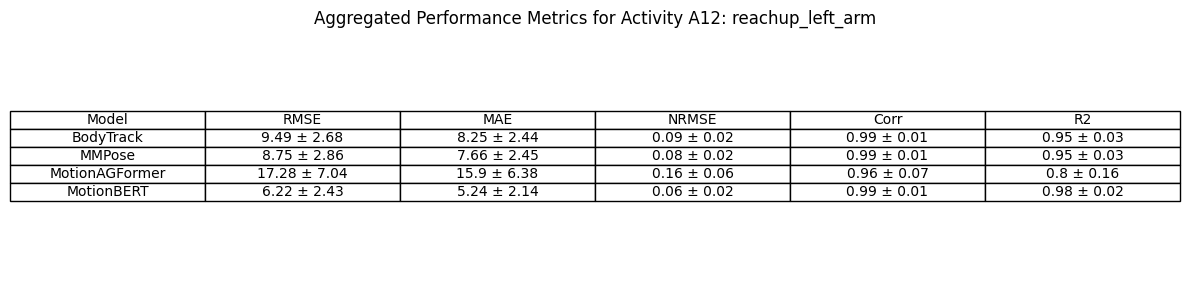

Processing Activity A13: tear_both_arms


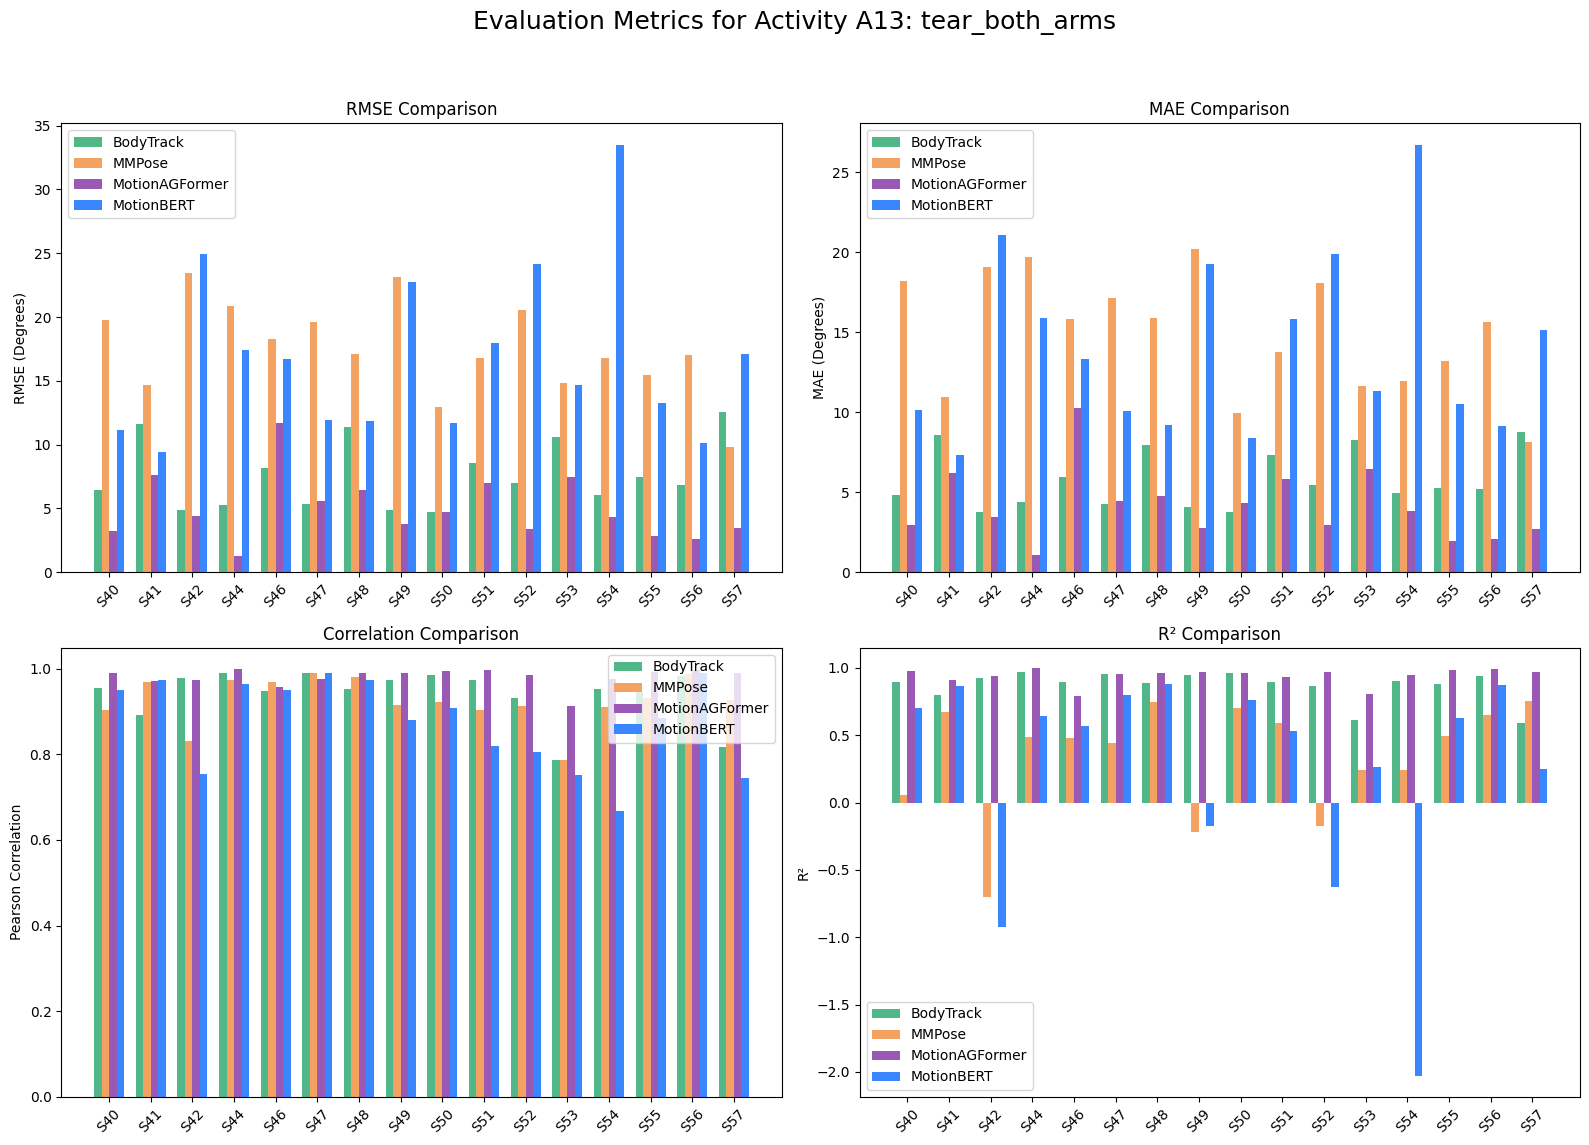

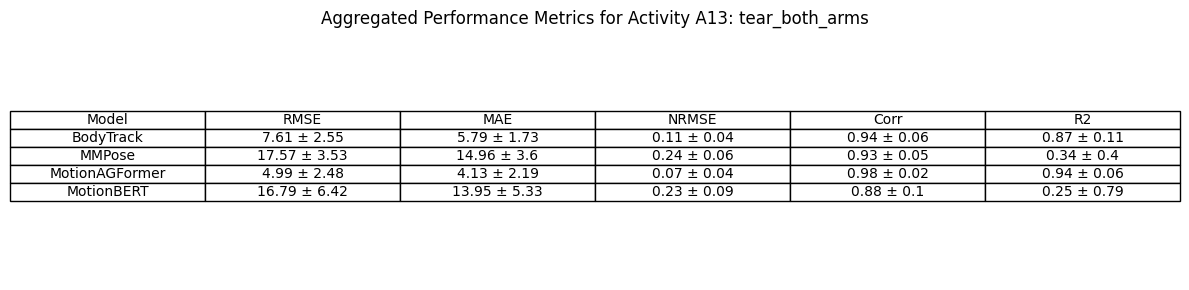

In [4]:
import os
import sys
import platform

sys.path.append(os.path.dirname(os.getcwd()))
from benchmark_utils.sync_utils import plotFramesShiftToSyncrhonizeAllSubjectsOneActivity,getMainJointFromMotAndMainBonesFromCSV, getSamplesToSynchronize, SynchronizeAndCutSignals
from benchmark_utils.compare_utils import *
import benchmark_utils.file_utils as fileutil 
import benchmark_utils.plot_utils as plotutil
import benchmark_utils.signal_utils as signalutil
import benchmark_utils.evaluation_utils as evaluation_utils

# 1) Parámetros generales
dataset_path = '/Users/mario/Documents/vidimu_pipeline_COPIA/benchmark'

# 2) Nuevos directorios de entrada
in_path_bodytrack       = os.path.join(dataset_path, 'jointangles', 'jointangles_bodytrack')
in_path_motionbert      = os.path.join(dataset_path, 'jointangles', 'jointangles_motionbert')
in_path_mmpose          = os.path.join(dataset_path, 'jointangles', 'jointangles_mmpose')
in_path_motionagformer  = os.path.join(dataset_path, 'jointangles', 'jointangles_motionagformer')
in_path_imus            = os.path.join(dataset_path, 'jointangles', 'jointangles_imus')

# 3) Directorios de salida
out_path_eval = os.path.join(dataset_path, 'results', 'evaluation', 'PARAELTFG')
out_path_comp = os.path.join(dataset_path, 'results', 'comparison','PARAELTFG')
os.makedirs(out_path_eval, exist_ok=True)
os.makedirs(out_path_comp, exist_ok=True)

# 4) Definición de actividades y sujetos
lower_activities   = ["A01","A02","A03","A04"]
upper_activities   = ["A05","A06","A07","A08","A09","A10","A11","A12","A13"]
dataset_activities = lower_activities + upper_activities
activities_legend  = [
    "walk_forward", "walk_backward", "walk_along","sit_to_stand",
    "move_right_arm","move_left_arm","drink_right_arm","drink_left_arm",
    "assemble_both_arms","throw_both_arms",
    "reachup_right_arm","reachup_left_arm","tear_both_arms"
]
activities_dict    = dict(zip(dataset_activities, activities_legend))
selected_subjects  = [f"S{n}" for n in range(40,58) if n!=43 and n!=45]  # S40...S57 sin S43 y S45

# 5) Parámetros de sincronización/filtrado
RMSE_SAMPLES    = 180
FINAL_LENGTH    = 180
MAX_SYNC_OVERLAP= 15

# 6) Bucle principal: cálculo y guardado de métricas por actividad
per_activity_summaries = {}
for act, legend in zip(dataset_activities, activities_legend):
    print(f"Processing Activity {act}: {legend}")
    metrics_results = evaluation_utils.calculateAndPlotAllMetrics(
        csv_bodytrack_path=in_path_bodytrack,
        csv_motionbert_path=in_path_motionbert,
        csv_mmpose_path=in_path_mmpose,
        csv_motionagformer_path=in_path_motionagformer,
        imu_inpath=in_path_imus,
        subjects=selected_subjects,
        activity=act,
        activity_legend=legend,
        RMSE_SAMPLES=RMSE_SAMPLES,
        MAX_SYNC_OVERLAP=MAX_SYNC_OVERLAP,
        FINAL_LENGTH=FINAL_LENGTH,
        out_path=out_path_eval,
        filename_prefix=f"{act}_BarCharts"
    )
    # Resumen y tabla
    summary_df = evaluation_utils.createSummaryTable(metrics_results)
    evaluation_utils.plotSummaryTable(
        summary_df,
        title=f"Aggregated Performance Metrics for Activity {act}: {legend}",
        out_path=out_path_eval,
        filename_prefix=f"{act}_SummaryTable"
    )
    per_activity_summaries[act] = summary_df


Activity MAE Comparison Table
ID                      Legend      MotionAGFormer          MotionBERT              MMPose           BodyTrack
--------------------------------------------------------------------------------
A01               walk_forward         6.15 ± 2.68         5.56 ± 1.79       *4.90 ± 1.75*         5.28 ± 1.93
A02              walk_backward         5.16 ± 1.94         5.23 ± 1.73         4.65 ± 1.62       *3.74 ± 1.12*
A03                 walk_along       *4.43 ± 2.06*         5.28 ± 1.80         4.76 ± 1.71         4.65 ± 1.60
A04               sit_to_stand        10.88 ± 7.15       *4.48 ± 1.68*         7.87 ± 2.12         6.22 ± 2.87
A05             move_right_arm       *5.00 ± 2.25*        11.61 ± 3.02         8.92 ± 2.55        10.80 ± 2.70
A06              move_left_arm      *15.56 ± 8.21*        29.70 ± 6.90        16.65 ± 5.69        22.19 ± 7.54
A07            drink_right_arm       *4.64 ± 2.54*         7.15 ± 3.00         7.01 ± 3.27        13.33 ± 3.57
A

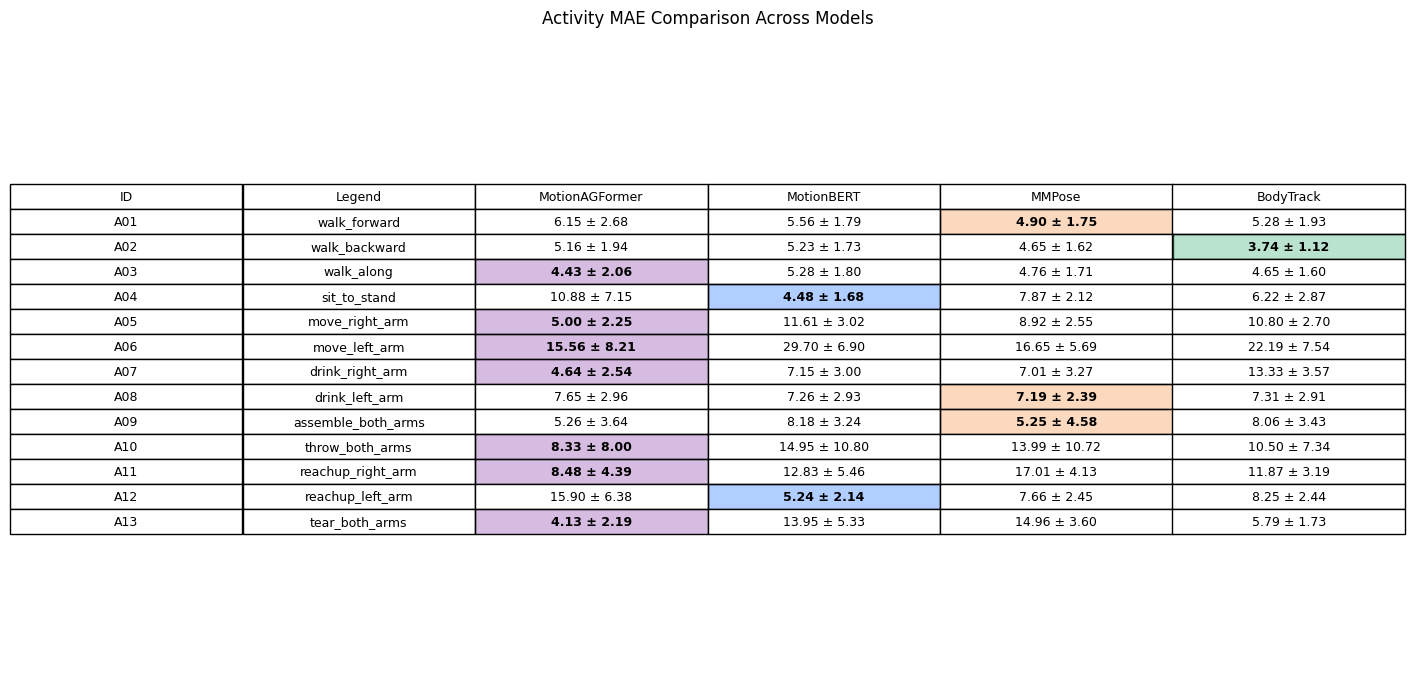

Activity R² Comparison Table
ID                      Legend      MotionAGFormer          MotionBERT              MMPose           BodyTrack
--------------------------------------------------------------------------------
A01               walk_forward         0.64 ± 0.26         0.68 ± 0.24       *0.76 ± 0.20*         0.71 ± 0.29
A02              walk_backward         0.61 ± 0.30         0.58 ± 0.35         0.67 ± 0.32       *0.80 ± 0.10*
A03                 walk_along         0.81 ± 0.15         0.74 ± 0.12         0.80 ± 0.12       *0.81 ± 0.10*
A04               sit_to_stand         0.73 ± 0.31       *0.95 ± 0.04*         0.87 ± 0.06         0.89 ± 0.14
A05             move_right_arm       *0.79 ± 0.16*        -0.12 ± 1.02         0.45 ± 0.30         0.08 ± 0.60
A06              move_left_arm      *-0.76 ± 1.29*        -4.99 ± 2.30        -0.91 ± 0.72        -2.51 ± 1.72
A07            drink_right_arm       *0.92 ± 0.07*         0.80 ± 0.13         0.81 ± 0.19         0.46 ± 0.21
A0

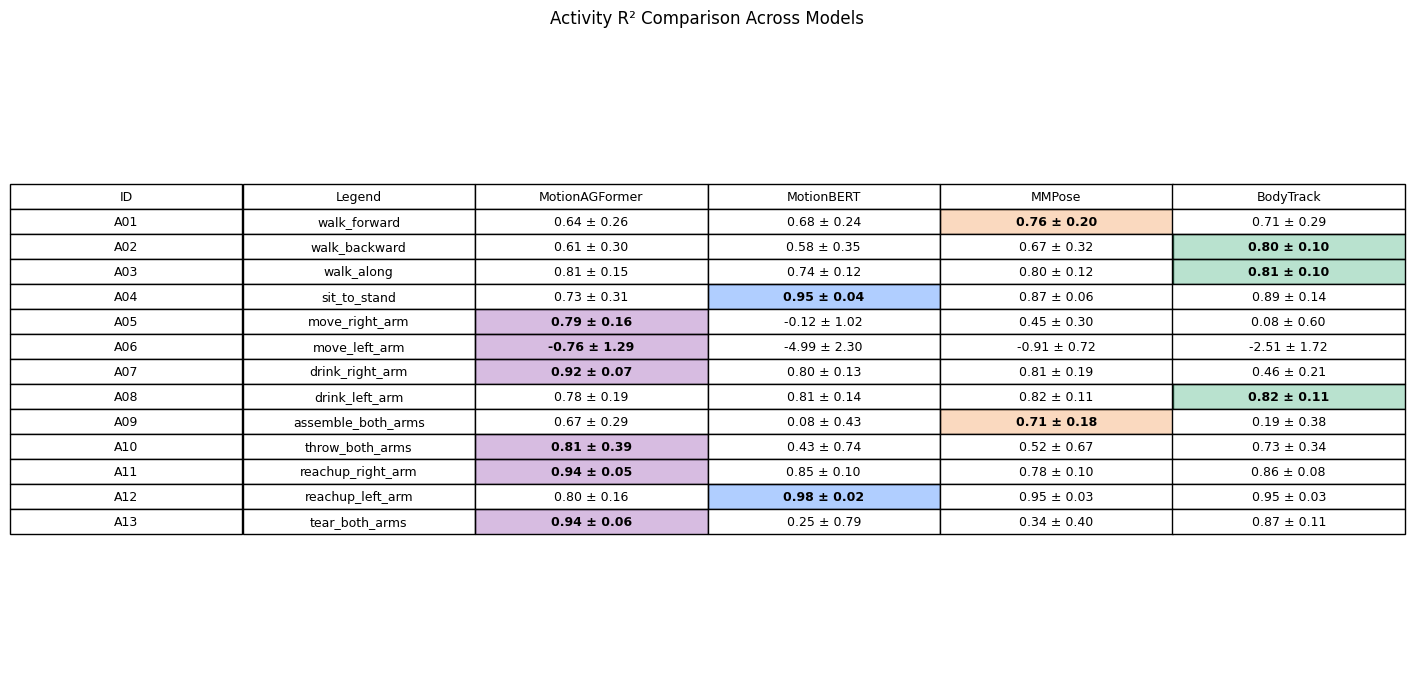

Tablas comparativas generadas en: /Users/mario/Documents/vidimu_pipeline_COPIA/benchmark/results/comparison/PARAELTFG


In [5]:

# 7) Generar tablas comparativas globales (RMSE, MAE y R²)

mae_table = evaluation_utils.createActivityMAEComparisonTable(
    per_activity_summaries, activities_dict,
    out_path=out_path_comp,
    filename_prefix="Overall_PerActivityMAE_Table"
)

r2_table = evaluation_utils.createActivityR2ComparisonTable(
    per_activity_summaries, activities_dict,
    out_path=out_path_comp,
    filename_prefix="Overall_PerActivityR2_Table"
)

print("Tablas comparativas generadas en:", out_path_comp)
